<a href="https://colab.research.google.com/github/125jkop/SSD_BABP/blob/main/01_Courses/A_Bioinformatics/Week02_Weather_Analysis/BABP_A_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BABP 2주차: 피부로 느끼는 데이터 분석 (날씨 데이터 분석하기)

## 0. 환경 설정
본격적인 코드의 실행 전, 작업 환경을 미리 설정하는 과정입니다.<br>




### 0-1. 데이터 로드
컴퓨터 파일 시스템에서 파일들을 분류하고 관리하기 위한 계층적 공간을 '디렉토리(directory)'라고 합니다.<br>
우리가 흔히 '폴더'라고 부르는 그것이에요.


프로그래밍 중 필요한 파일은 기본적으로 현재 작업 중인 디렉토리 내부에 존재해야 합니다.<br>
저희가 이번에 진행할 데이터 분석도 미리 데이터 파일을 그 디렉토리에 위치시켜야 하죠.<br>

아래의 코드를 실행해봅시다. 코드의 실행은 마우스 커서를 그 코드가 있는 칸('셀(cell)'이라고 부릅니다!) 위에 올렸을 때 나타나는 재생 버튼을 누르시면 됩니다. 또는, 간단히 그 셀을 클릭한 뒤 'Shift + Enter'를 누르는 것으로 실행할 수 있습니다(이 방법을 더 많이 사용해요!).

In [1]:
!pwd   # pwd(print working directory): 현재 작업 중인 디렉토리를 출력

/content


pwd를 통해 현재 우리의 위치가 `/content`임을 알 수 있었습니다.<br>

코랩에서는 좌측의 폴더 모양 아이콘을 눌러 디렉토리 내부에 무엇이 있는지 확인할 수 있습니다. `/content` 내부에는 `/sample_data`라는 하위 디렉토리만이 있네요.<br>

앞서 다운로드한 데이터 파일을 드래그하여 `/content` 내부로 옮겨봅시다. 코랩이 클라우드 기반 서비스이기 때문에 데이터의 용량이 크다면 서버에 업로드하는데 약간의 시간이 걸릴 수 있습니다.<br>

※ 주의: `/sample_data` 내부로 들어가지 않도록 해주세요. 컴퓨터는 `/content`와 `/content/sample_data`를 다른 경로로 인식하기 때문에, 현재 저희가 작업 중인 위치에서는 '/sample_data' 내부의 파일에 접근할 수 없습니다.

### 0-2. 폰트 다운로드
보통 연구 현장에서는 영어로 그래프를 그리지만, 오늘은 한국어로도 만들 수 있음을 보여드리고자 합니다.<br>
 다만 기본적으로 한국어 폰트를 지원하지 않기 때문에 따로 설치를 진행해야 합니다. 아래의 코드를 실행해주세요.

In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

지금과 같이 폰트나, 라이브러리 등 다른 패키지를 다운로드한 후에는 항상 커널(Kernel)을 종료 후 재시작해줘야 합니다.<br> 코랩의 경우 상단의 '런타임' → '세션 다시 시작'을 누르는 것으로 할 수 있습니다.<br> 재시작 후 다음 코드로 넘어갑시다.

### 0-3. 라이브러리 불러오기
1주차에서 언급했듯이, 파이썬의 강점은 높은 접근성에 기반한 확장성에 있습니다.<br>
우리는 간단히 미리 만들어진 좋은 코드 뭉치, 즉 라이브러리를 import하여 활용할 수 있습니다.<br>

이번 주차에서 활용할 라이브러리는 pandas, matplotlib, numpy, 그리고 google.colab의 files입니다.<br>
각 라이브러리에 대한 자세한 설명은 코드를 그대로 복사 및 붙여넣기하여 해설해달라고 해보세요. 저보다도 설명은 정말 잘할겁니다. <br>
저도 코드에 '#'으로 주석을 달아 설명해두었으니, AI와 주석을 함께 확인하시면서 따라온다면 큰 문제 없을 겁니다.

In [3]:
# Import libraries
import pandas as pd               # 2차원 데이터 처리 도구
import matplotlib.pyplot as plt   # 그래프 시각화 도구
import numpy as np                # 고효율 숫자 배열 처리 도구
from google.colab import files    # 코랩에서 파일을 저장하기 위함

# Set fonts
plt.rc('font', family='NanumBarunGothic')

## 1. 기상학적 정의에 따라 계절 구분하기
계절은 흔히 3월부터 5월을 봄, 6월부터 8월을 여름, 9월부터 11월을 가을, 12월부터 1월까지를 겨울로 구분하곤 합니다. 또는 천문학적 정의에 따라 지구의 자전축과 공전 위치에 따라서도 구분할 수 있습니다.<br>

다만, 기상청에서 말하는 기상학적 정의에 따른 계절은 아래와 같습니다.<br>

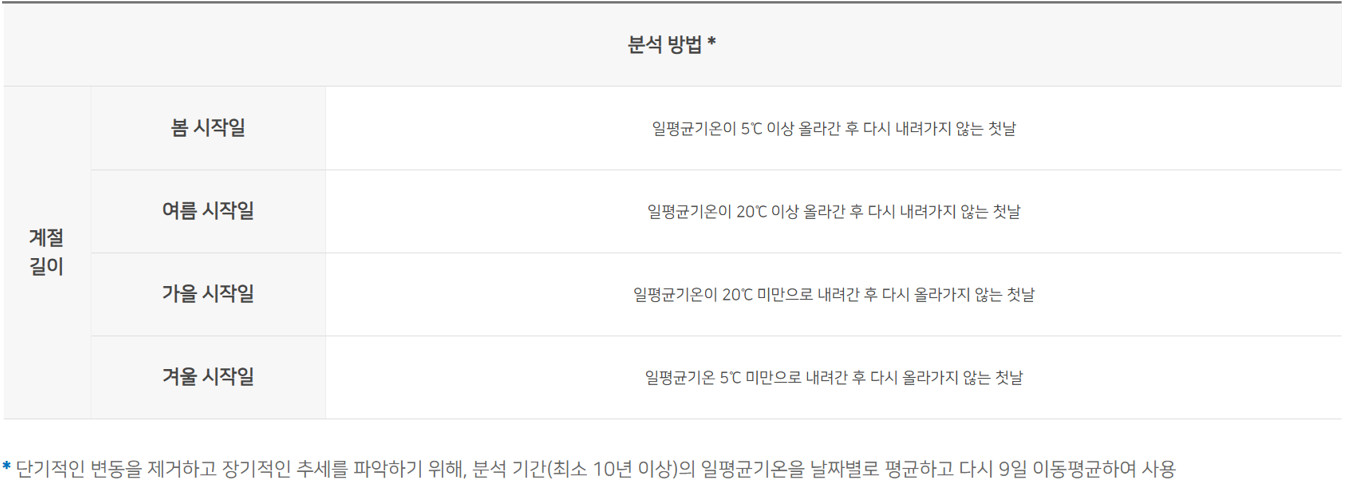

쉽게 말해, 하루의 평균 기온을 측정하고 다시 9일 이동평균한 값으로 5°C, 20°C라는 기준에 맞춰 계절을 구분한다는 뜻입니다.
이 기준에 따라 우리의 데이터를 구분하고 색을 입혀 시각화해봅시다.

/tmp/ipykernel_30292/884696669.py:60: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig('2025년 대전 기온 변화 및 계절 구분.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


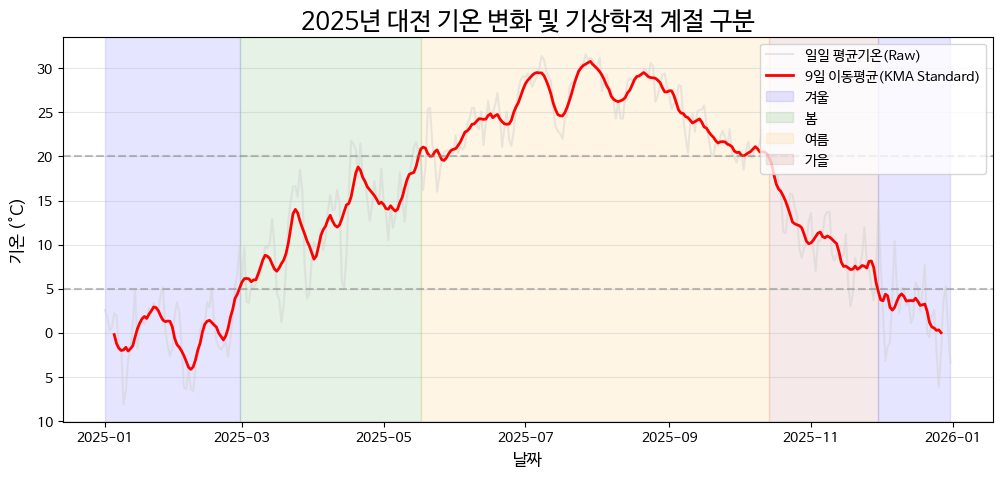

In [6]:
# 1. 데이터 불러오기
# 데이터의 구조가 2차원 행렬이니 곧바로 입력해서 사용할 수 있습니다.
df = pd.read_csv('DSG_temp_2025.csv', encoding='cp949')

# 2. 데이터 전처리
df['일시'] = pd.to_datetime(df['일시'])
df = df[df['지점'] == 133].sort_values('일시')  # 대전 지점만 필터링 및 정렬

# 3. 9일 이동평균 계산
df['평균기온_MA'] = df['평균기온(°C)'].rolling(window=9, center=True).mean()

# 4. 계절 구분
# 연간 흐름을 고려하여 상반기/하반기로 나누어 임계점 통과일을 찾습니다.
# 역치가 섭씨 5도와 20도라는 2개로 이루어졌기 때문에, 2개의 기준으로 4개의 구분을 할 수는 없습니다.
# 따라서 1년이 365일이므로 그 절반인 약 180일을 기준으로 다시 나누어, 앞의 180일을 전반, 뒤의 180일을 후반으로 나누어 생각합시다.

def get_season_start(series, threshold, direction='up', period='first_half'):
    if period == 'first_half':
        sub_series = series[:180] # 대략 6월 이전: 봄과 여름이 해당
    else:
        sub_series = series[180:] # 7월 이후: 가을과 겨울이 해당

    if direction == 'up':
        found = sub_series[sub_series >= threshold]
    else:
        found = sub_series[sub_series < threshold]

    return found.index[0] if not found.empty else None

spring_start = get_season_start(df['평균기온_MA'], 5, 'up', 'first_half')       # 전반이며, 9일 이동평균 기온이 처음으로 섭씨 5도에 도달 - 봄
summer_start = get_season_start(df['평균기온_MA'], 20, 'up', 'first_half')      # 전반이며, 9일 이동평균 기온이 처음으로 섭씨 20도에 도달 - 여름
autumn_start = get_season_start(df['평균기온_MA'], 20, 'down', 'second_half')   # 후반이며, 9일 이동평균 기온이 처음으로 섭씨 20도에 도달 - 가을
winter_start = get_season_start(df['평균기온_MA'], 5, 'down', 'second_half')    # 후반이며, 9일 이동평균 기온이 처음으로 섭씨 5도에 도달 - 겨울

# 5. 시각화
plt.figure(figsize=(12, 5))

# Raw Data와 이동평균선 그리기
plt.plot(df['일시'], df['평균기온(°C)'], color='lightgray', alpha=0.5, label='일일 평균기온(Raw)')
plt.plot(df['일시'], df['평균기온_MA'], color='red', linewidth=2, label='9일 이동평균(KMA Standard)')

# 계절별 배경색(Patch) 입히기
plt.axvspan(df['일시'].min(), df.loc[spring_start, '일시'], color='blue', alpha=0.1, label='겨울')
plt.axvspan(df.loc[spring_start, '일시'], df.loc[summer_start, '일시'], color='green', alpha=0.1, label='봄')
plt.axvspan(df.loc[summer_start, '일시'], df.loc[autumn_start, '일시'], color='orange', alpha=0.1, label='여름')
plt.axvspan(df.loc[autumn_start, '일시'], df.loc[winter_start, '일시'], color='brown', alpha=0.1, label='가을')
plt.axvspan(df.loc[winter_start, '일시'], df['일시'].max(), color='blue', alpha=0.1)

# 기준선 표시
plt.axhline(5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(20, color='gray', linestyle='--', alpha=0.5)

# 텍스트 및 디자인
plt.title('2025년 대전 기온 변화 및 기상학적 계절 구분', fontsize=18)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('기온 (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.savefig('2025년 대전 기온 변화 및 계절 구분.png')
# files.download('2025년 대전 기온 변화 및 계절 구분.png')   # 주석 처리 되어 있습니다, 다운로드를 원하시면 '#'을 지워서 실행해보세요.
plt.show()

코드의 효율성은 알고리즘 최적화도 있지만, 얼마나 재활용할 수 있는지도 중요합니다.<br>

위의 코드는 아래 분석에서도 계속해서 사용되니, 한 번만 이해하면 계속해서 이해하실 수 있을겁니다.

## 2. 과거와 현재의 대전의 기온과 계절 비교하기

이제 본격적인 분석 단계로 넘어가봅시다.<br>
먼저 시간의 차이에 따른 계절의 변화가 있는지를 확인해봅시다.<br>

데이터의 해석이란 우리가 이미 알고 있는 지식으로 현재 자신이 갖고 있는 데이터를 설명하고 연결짓는 과정입니다.<br>
우리는 이미 지난 50년간 인간 활동으로 인해 지구온난화가 진행 중이라는 사실을 알고 있으니, 흔히 우리들은 다음과 같은 가설을 갖고 있습니다.<br>

**가설: "지구온난화로 인해 봄과 가을이 줄어들고 여름과 겨울이 늘어났다."**

이 가설이 맞는지 확인하기 위해, 이번에는 1975년 대전의 기온을 분석해봅시다.<br>
위의 코드에서 몇 글자만 바꾸면 됩니다.

/tmp/ipykernel_30292/3490922270.py:60: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig('1975년 대전 기온 변화 및 계절 구분.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


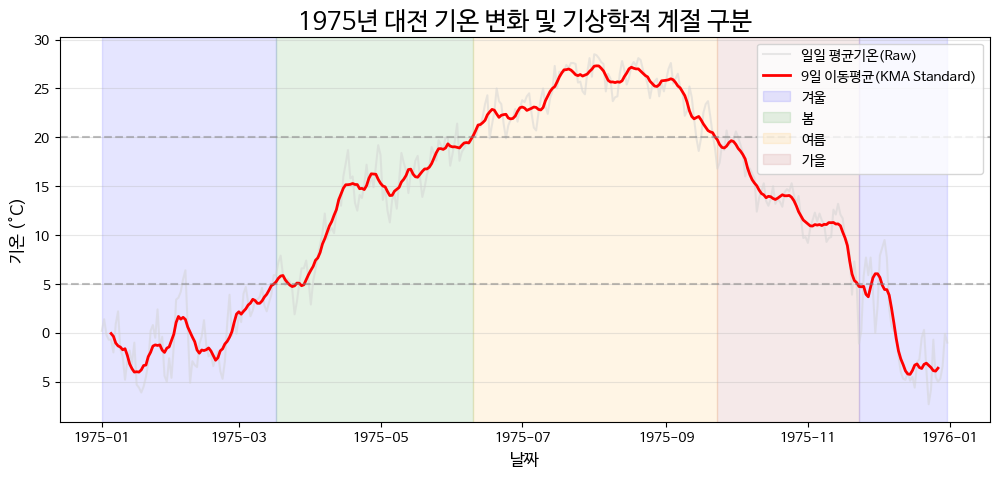

In [7]:
# 1. 데이터 불러오기
# 데이터의 구조가 2차원 행렬이니 곧바로 입력해서 사용할 수 있습니다.
df = pd.read_csv('DSG_temp_1975.csv', encoding='cp949')

# 2. 데이터 전처리
df['일시'] = pd.to_datetime(df['일시'])
df = df[df['지점'] == 133].sort_values('일시')  # 대전 지점만 필터링 및 정렬

# 3. 9일 이동평균 계산
df['평균기온_MA'] = df['평균기온(°C)'].rolling(window=9, center=True).mean()

# 4. 계절 구분
# 연간 흐름을 고려하여 상반기/하반기로 나누어 임계점 통과일을 찾습니다.
# 역치가 섭씨 5도와 20도라는 2개로 이루어졌기 때문에, 2개의 기준으로 4개의 구분을 할 수는 없습니다.
# 따라서 1년이 365일이므로 그 절반인 약 180일을 기준으로 다시 나누어, 앞의 180일을 전반, 뒤의 180일을 후반으로 나누어 생각합시다.

def get_season_start(series, threshold, direction='up', period='first_half'):
    if period == 'first_half':
        sub_series = series[:180] # 대략 6월 이전: 봄과 여름이 해당
    else:
        sub_series = series[180:] # 7월 이후: 가을과 겨울이 해당

    if direction == 'up':
        found = sub_series[sub_series >= threshold]
    else:
        found = sub_series[sub_series < threshold]

    return found.index[0] if not found.empty else None

spring_start = get_season_start(df['평균기온_MA'], 5, 'up', 'first_half')       # 전반이며, 9일 이동평균 기온이 처음으로 섭씨 5도에 도달 - 봄
summer_start = get_season_start(df['평균기온_MA'], 20, 'up', 'first_half')      # 전반이며, 9일 이동평균 기온이 처음으로 섭씨 20도에 도달 - 여름
autumn_start = get_season_start(df['평균기온_MA'], 20, 'down', 'second_half')   # 후반이며, 9일 이동평균 기온이 처음으로 섭씨 20도에 도달 - 가을
winter_start = get_season_start(df['평균기온_MA'], 5, 'down', 'second_half')    # 후반이며, 9일 이동평균 기온이 처음으로 섭씨 5도에 도달 - 겨울

# 5. 시각화
plt.figure(figsize=(12, 5))

# Raw Data와 이동평균선 그리기
plt.plot(df['일시'], df['평균기온(°C)'], color='lightgray', alpha=0.5, label='일일 평균기온(Raw)')
plt.plot(df['일시'], df['평균기온_MA'], color='red', linewidth=2, label='9일 이동평균(KMA Standard)')

# 계절별 배경색(Patch) 입히기
plt.axvspan(df['일시'].min(), df.loc[spring_start, '일시'], color='blue', alpha=0.1, label='겨울')
plt.axvspan(df.loc[spring_start, '일시'], df.loc[summer_start, '일시'], color='green', alpha=0.1, label='봄')
plt.axvspan(df.loc[summer_start, '일시'], df.loc[autumn_start, '일시'], color='orange', alpha=0.1, label='여름')
plt.axvspan(df.loc[autumn_start, '일시'], df.loc[winter_start, '일시'], color='brown', alpha=0.1, label='가을')
plt.axvspan(df.loc[winter_start, '일시'], df['일시'].max(), color='blue', alpha=0.1)

# 기준선 표시
plt.axhline(5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(20, color='gray', linestyle='--', alpha=0.5)

# 텍스트 및 디자인
plt.title('1975년 대전 기온 변화 및 기상학적 계절 구분', fontsize=18)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('기온 (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.savefig('1975년 대전 기온 변화 및 계절 구분.png')
# files.download('1975년 대전 기온 변화 및 계절 구분.png')   # 주석 처리 되어 있습니다, 다운로드를 원하시면 '#'을 지워서 실행해보세요.
plt.show()

1975년의 대전 계절 구분과 2025년의 대전 계절 구분 그림을 서로 비교해보세요(pdf에도 있답니다).<br>
여름은 늘어났지만, 봄, 가을, 겨울은 줄어들었다는 것을 알 수 있습니다.<br> 특히, 봄은 이전에 비해 훨씬 이르게 시작되고 있다는 것을 알 수 있습니다.

## 3. 현재 여러 지역의 기온과 계절 비교하기
다음으로는 여러 지역의 2025년 기온과 계절을 비교해봅시다.<br>
경기도에 위치한 수원과 충청도에 위치한 대전, 경상도에 위치한 거제 지역을 각각 비교해봅시다.

이번에도 우리는 각 지역에서 위도의 차이가 있다는 점을 알고 있기 때문에, 다음의 가설을 떠올릴 수 있습니다.

**가설: "고위도 지역은 저위도 지역에 비해 겨울이 더 짧고, 여름이 더 길 것이다."**

/tmp/ipykernel_30292/3724872616.py:56: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig('2025년 수원 기온 변화 및 계절 구분.png')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


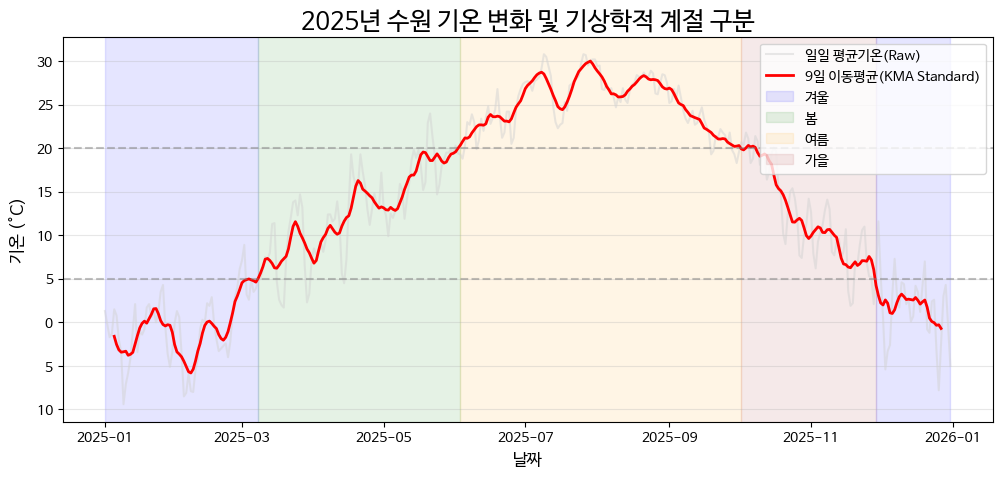

In [9]:
# 1. 데이터 불러오기
df = pd.read_csv('DSG_temp_2025.csv', encoding='cp949')

# 2. 데이터 전처리
df['일시'] = pd.to_datetime(df['일시'])
df = df[df['지점'] ==119].sort_values('일시')  # 수원(119) 지점만 필터링 및 정렬

# 3. 9일 이동평균 계산 (기상청 기준)
df['평균기온_MA'] = df['평균기온(°C)'].rolling(window=9, center=True).mean()

# 4. 계절 구분 (간소화된 기상청 로직 적용)
# 연간 흐름을 고려하여 상반기/하반기로 나누어 임계점 통과일을 찾는다요.
def get_season_start(series, threshold, direction='up', period='first_half'):
    if period == 'first_half':
        sub_series = series[:180] # 대략 6월 이전
    else:
        sub_series = series[180:] # 7월 이후

    if direction == 'up':
        found = sub_series[sub_series >= threshold]
    else:
        found = sub_series[sub_series < threshold]

    return found.index[0] if not found.empty else None

spring_start = get_season_start(df['평균기온_MA'], 5, 'up', 'first_half')
summer_start = get_season_start(df['평균기온_MA'], 20, 'up', 'first_half')
autumn_start = get_season_start(df['평균기온_MA'], 20, 'down', 'second_half')
winter_start = get_season_start(df['평균기온_MA'], 5, 'down', 'second_half')

# 5. 시각화
plt.figure(figsize=(12, 5))

# Raw Data와 이동평균선 그리기
plt.plot(df['일시'], df['평균기온(°C)'], color='lightgray', alpha=0.5, label='일일 평균기온(Raw)')
plt.plot(df['일시'], df['평균기온_MA'], color='red', linewidth=2, label='9일 이동평균(KMA Standard)')

# 계절별 배경색(Patch) 입히기
plt.axvspan(df['일시'].min(), df.loc[spring_start, '일시'], color='blue', alpha=0.1, label='겨울')
plt.axvspan(df.loc[spring_start, '일시'], df.loc[summer_start, '일시'], color='green', alpha=0.1, label='봄')
plt.axvspan(df.loc[summer_start, '일시'], df.loc[autumn_start, '일시'], color='orange', alpha=0.1, label='여름')
plt.axvspan(df.loc[autumn_start, '일시'], df.loc[winter_start, '일시'], color='brown', alpha=0.1, label='가을')
plt.axvspan(df.loc[winter_start, '일시'], df['일시'].max(), color='blue', alpha=0.1)

# 기준선 표시
plt.axhline(5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(20, color='gray', linestyle='--', alpha=0.5)

# 텍스트 및 디자인
plt.title('2025년 수원 기온 변화 및 기상학적 계절 구분', fontsize=18)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('기온 (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.savefig('2025년 수원 기온 변화 및 계절 구분.png')
# files.download('2025년 수원 기온 변화 및 계절 구분.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

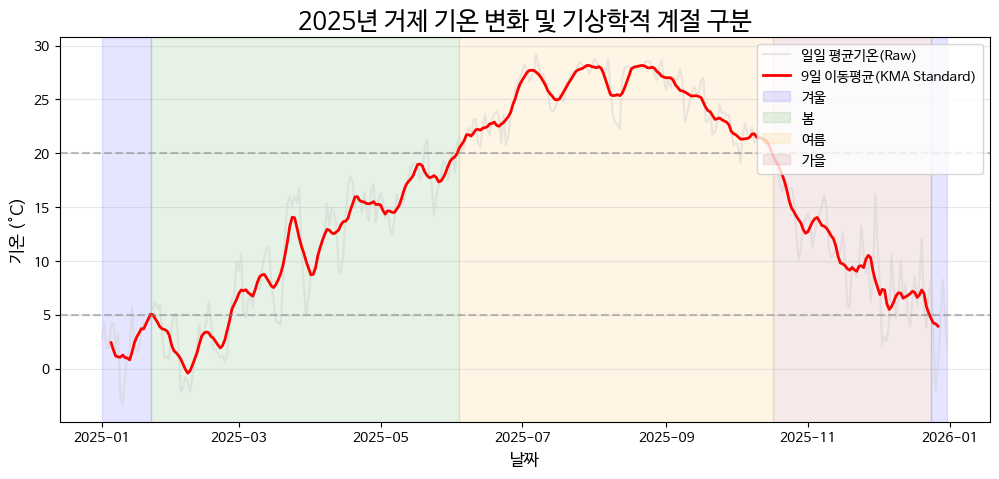

In [10]:
# 1. 데이터 불러오기
df = pd.read_csv('DSG_temp_2025.csv', encoding='cp949')

# 2. 데이터 전처리
df['일시'] = pd.to_datetime(df['일시'])
df = df[df['지점'] == 294].sort_values('일시')  # 거제(294) 지점만 필터링 및 정렬

# 3. 9일 이동평균 계산 (기상청 기준)
df['평균기온_MA'] = df['평균기온(°C)'].rolling(window=9, center=True).mean()

# 4. 계절 구분 (간소화된 기상청 로직 적용)
# 연간 흐름을 고려하여 상반기/하반기로 나누어 임계점 통과일을 찾는다요.
def get_season_start(series, threshold, direction='up', period='first_half'):
    if period == 'first_half':
        sub_series = series[:180] # 대략 6월 이전
    else:
        sub_series = series[180:] # 7월 이후

    if direction == 'up':
        found = sub_series[sub_series >= threshold]
    else:
        found = sub_series[sub_series < threshold]

    return found.index[0] if not found.empty else None

spring_start = get_season_start(df['평균기온_MA'], 5, 'up', 'first_half')
summer_start = get_season_start(df['평균기온_MA'], 20, 'up', 'first_half')
autumn_start = get_season_start(df['평균기온_MA'], 20, 'down', 'second_half')
winter_start = get_season_start(df['평균기온_MA'], 5, 'down', 'second_half')

# 5. 시각화
plt.figure(figsize=(12, 5))

# Raw Data와 이동평균선 그리기
plt.plot(df['일시'], df['평균기온(°C)'], color='lightgray', alpha=0.5, label='일일 평균기온(Raw)')
plt.plot(df['일시'], df['평균기온_MA'], color='red', linewidth=2, label='9일 이동평균(KMA Standard)')

# 계절별 배경색(Patch) 입히기
plt.axvspan(df['일시'].min(), df.loc[spring_start, '일시'], color='blue', alpha=0.1, label='겨울')
plt.axvspan(df.loc[spring_start, '일시'], df.loc[summer_start, '일시'], color='green', alpha=0.1, label='봄')
plt.axvspan(df.loc[summer_start, '일시'], df.loc[autumn_start, '일시'], color='orange', alpha=0.1, label='여름')
plt.axvspan(df.loc[autumn_start, '일시'], df.loc[winter_start, '일시'], color='brown', alpha=0.1, label='가을')
plt.axvspan(df.loc[winter_start, '일시'], df['일시'].max(), color='blue', alpha=0.1)

# 기준선 표시
plt.axhline(5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(20, color='gray', linestyle='--', alpha=0.5)

# 텍스트 및 디자인
plt.title('2025년 거제 기온 변화 및 기상학적 계절 구분', fontsize=18)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('기온 (°C)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.savefig('2025년 거제 기온 변화 및 계절 구분.png')
# files.download('2025년 거제 기온 변화 및 계절 구분.png')
plt.show()

세 지역의 그림을 서로 비교해보세요(마찬가지로 pdf에 있답니다).<br>
저희의 가설이 얼추 맞았던 것 같습니다.<br>
특히 거제 지역은 봄이 매우 기네요. 이를 통해 우리는 거제가 해안 지역이기 때문에 여름만큼 봄이 길 수도 있겠다는 가설을 다시 세워볼 수 있습니다.<br>
다만 저희의 데이터에는 평균 기온밖에 없기 때문에, 이 가설의 검증을 위해서는 추가 데이터가 필요할 것입니다.<br>
<br>
이런 식으로 검증하고자 하는 사실에 따라서 데이터의 수집, 처리, 분석 과정이 달라질 수 있다는 점을 알고 가신다면,<br> 앞으로의 분석에 있어 실험 디자인에 대한 통찰과 방법에 대해서 어떤 것이 내 목적에 맞는 좋은 분석일지 고민하며 성장할 수 있을 것입니다.

## 4. 충남대학교의 하늘에 내리는 '희고 흰 것'


잘 따라오고 계신가요? 오늘 마지막으로 해볼 것은 마침 봄이기도 하니, 충남대학교의 하늘에 내리는 '희고 흰 것'들<br> 다시 말해 첫눈과 벚꽃이 내리고 피는 날을 한 번 함께 확인해봅시다.<br>

마침 대전의 기상 관측기가 유성구 구성동에 있다고 하니, 충남대학교와의 거리를 고려했을 때 크게 다르지 않을 것이라고 가정할 수 있습니다.

우리가 생물 데이터를 분석할 때, 샘플들을 구분하기 위한 마커가 항상 필요합니다.<br>
나이나 성별은 표현형으로 드러날 수 있지만, 질병과 같은 기준은 분자 수준으로 들어가야 하죠.<br>

저희의 목적이었던 계절 데이터에서는 어떤 것이 마커가 될 수 있을까요?<br>
바로 첫눈은 겨울의 마커, 벚꽃은 봄의 마커가 될 수 있을 겁니다.<br>

위에서 확인한 우리의 결과인 '겨울이 짧아지고 있다'를 날씨와 식물 마커를 통해 검증해보도록 합시다.

/tmp/ipykernel_30292/1505220874.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['벚꽃_날짜'] = pd.to_datetime(df['벚나무'], errors='coerce')
/tmp/ipykernel_30292/1505220874.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['눈_날짜'] = pd.to_datetime(df['눈'], errors='coerce')
/tmp/ipykernel_30292/1505220874.py:51: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/tmp/ipykernel_30292/1505220874.py:52: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  plt.savefig('충남대학교 벚꽃과 첫눈.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


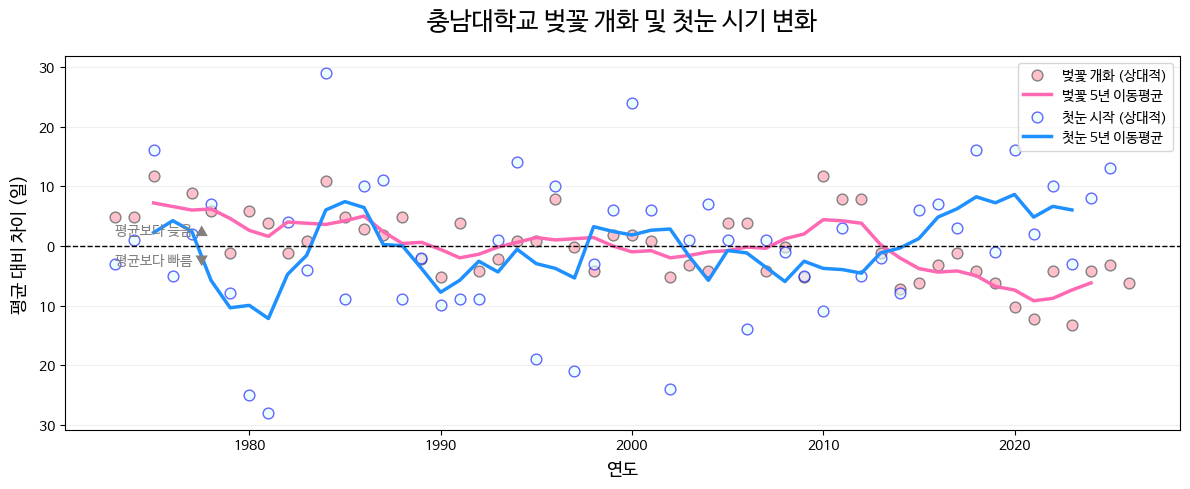

In [11]:
# 1. 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 2. 데이터 불러오기
df = pd.read_csv('D_whilte_ones.csv', encoding='cp949')

# 3. 데이터 전처리
# '결측' 등 변환 불가능한 값은 NaT로 만들고 제거한다요.
df['벚꽃_날짜'] = pd.to_datetime(df['벚나무'], errors='coerce')
df['눈_날짜'] = pd.to_datetime(df['눈'], errors='coerce')

# 연중 일수(Day of Year) 추출 함수
def get_doy(date_series):
    return date_series.dt.dayofyear

df['벚꽃_DOY'] = get_doy(df['벚꽃_날짜'])
df['눈_DOY'] = get_doy(df['눈_날짜'])

# 4. 상대적 일수 계산 (전체 기간 평균 대비)
bloom_mean = df['벚꽃_DOY'].mean()
snow_mean = df['눈_DOY'].mean()

df['상대_벚꽃'] = df['벚꽃_DOY'] - bloom_mean
df['상대_눈'] = df['눈_DOY'] - snow_mean

# 5. 시각화
plt.figure(figsize=(12, 5))

# 벚꽃 데이터 플롯
df_bloom = df.dropna(subset=['상대_벚꽃'])
plt.scatter(df_bloom['년도'], df_bloom['상대_벚꽃'], color='pink', s=60, label='벚꽃 개화 (상대적)', edgecolors='gray')
plt.plot(df_bloom['년도'], df_bloom['상대_벚꽃'].rolling(5, center=True).mean(), color='hotpink', linewidth=2.5, label='벚꽃 5년 이동평균')

# 눈 데이터 플롯
df_snow = df.dropna(subset=['상대_눈'])
plt.scatter(df_snow['년도'], df_snow['상대_눈'], color='lightcyan', s=60, label='첫눈 시작 (상대적)', edgecolors='blue', alpha=0.6)
plt.plot(df_snow['년도'], df_snow['상대_눈'].rolling(5, center=True).mean(), color='dodgerblue', linewidth=2.5, label='첫눈 5년 이동평균')

# 기준선 및 디자인
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('충남대학교 벚꽃 개화 및 첫눈 시기 변화', fontsize=18, pad=20)
plt.xlabel('연도', fontsize=13)
plt.ylabel('평균 대비 차이 (일)', fontsize=13)
plt.grid(True, axis='y', alpha=0.2)
plt.legend(loc='upper right')

# 해석을 위한 텍스트 추가
plt.text(df['년도'].min(), 2, '평균보다 늦음 ▲', fontsize=10, color='gray')
plt.text(df['년도'].min(), -3, '평균보다 빠름 ▼', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('충남대학교 벚꽃과 첫눈.png')
# files.download('충남대학교 벚꽃과 첫눈.png')
plt.show()

그래프를 보면 2010년대 초반까지는 요동치는 형태를 띠나, 그 이후부터 벚꽃의 개화는 평균보다 더 이르고, 첫눈의 날짜는 평균보다 더 늦어지고 있네요.<br>

이 결과는 우리의 가설(**겨울이 짧아지고 있다**)을 뒷받침합니다.

그렇다면 실제 문헌과 비교해볼까요? 언제나 선행 연구와의 교차 검증은 필요합니다.<br>
실제로, 겨울이 지속적으로 짧아지고 여름은 길어지고 있다는 내용을 어렵지 않게 [찾아볼 수](https://www.khan.co.kr/article/202512301024001) 있었습니다.

## 5. 마무리

지식과 데이터를 연결하는 과정, 이것이 수집(Collect) - 처리(Process) - 분석(Analyze)으로 이어지는 데이터 분석의 과정입니다.<br>
잘 와닿으셨을지 모르겠네요.<br>

여러분들도 기상청 데이터베이스로부터 자신의 고향의 기온을 가져와 분석해보거나,<br>
여름 철새나 코스모스를 비롯한 다른 식물과 같은 마커로 여름과 가을 등 다른 계절을 구분하고 비교해보시는 것도 재미있으실 겁니다.